In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)
np.set_printoptions(precision=3, suppress=True)

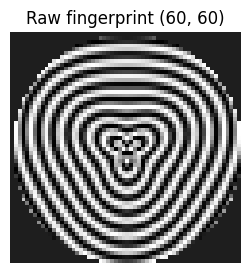

In [2]:
def make_fingerprint(size=60):
    """Synthetic fingerprint: concentric distorted ridge lines."""
    img = np.zeros((size, size), dtype=np.uint8)
    cx, cy = size / 2, size / 2
    yy, xx = np.mgrid[0:size, 0:size]
    dx, dy = xx - cx, yy - cy
    r = np.sqrt(dx**2 + dy**2)
    theta = np.arctan2(dy, dx)
    ridges = np.sin(r * 1.6 + 3 * np.sin(theta * 3))
    img = ((ridges + 1) / 2 * 255).astype(np.uint8)
    mask = r < size / 2
    img[~mask] = 30
    return img

fingerprint = make_fingerprint(60)
cv2.imwrite('data/fingerprint.png', fingerprint)

plt.figure(figsize=(3, 3))
plt.imshow(fingerprint, cmap='gray')
plt.title(f'Raw fingerprint {fingerprint.shape}')
plt.axis('off')
plt.savefig('output/t1_00_raw.png', bbox_inches='tight', dpi=150)
plt.show()

Scaling matrix S =
 [[3. 0.]
 [0. 3.]]
New canvas size: 180 x 180
Translation vector t = [0. 0.]
Full 2x3 affine matrix M =
 [[3. 0. 0.]
 [0. 3. 0.]]


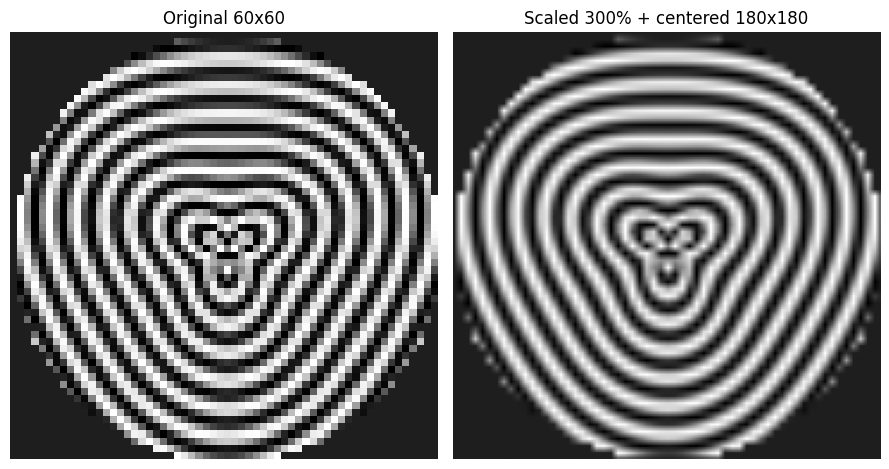

In [3]:
h, w = fingerprint.shape
sx, sy = 3.0, 3.0

S = np.array([
    [sx, 0.0],
    [0.0, sy]
])
print('Scaling matrix S =\n', S)

new_w, new_h = int(round(w * sx)), int(round(h * sy))
print(f'New canvas size: {new_w} x {new_h}')

old_center = np.array([w / 2, h / 2])
new_center = np.array([new_w / 2, new_h / 2])

t = new_center - S @ old_center
print('Translation vector t =', t)

M = np.hstack([S, t.reshape(2, 1)])
print('Full 2x3 affine matrix M =\n', M)

scaled = cv2.warpAffine(fingerprint, M, (new_w, new_h),
                         flags=cv2.INTER_LINEAR, borderValue=30)

fig, axes = plt.subplots(1, 2, figsize=(9, 5))
axes[0].imshow(fingerprint, cmap='gray')
axes[0].set_title(f'Original {w}x{h}')
axes[0].axis('off')
axes[1].imshow(scaled, cmap='gray')
axes[1].set_title(f'Scaled 300% + centered {new_w}x{new_h}')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/t1_01_scaled.png', bbox_inches='tight', dpi=150)
plt.show()